In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- one-time style setup: makes every chart in this notebook look consistent ----
sns.set_theme(style="whitegrid", font="DejaVu Sans")
PALETTE = ["#1F3864", "#2C6E9E", "#35B0A7", "#F5A623", "#D9534F", "#8E7CC3", "#4CAF50"]
sns.set_palette(PALETTE)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.3,
    "font.size": 10.5,
})

FILE = "fertilizer_market_data.xlsx"  

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- one-time style setup: makes every chart in this notebook look consistent ----
sns.set_theme(style="whitegrid", font="DejaVu Sans")
PALETTE = ["#1F3864", "#2C6E9E", "#35B0A7", "#F5A623", "#D9534F", "#8E7CC3", "#4CAF50"]
sns.set_palette(PALETTE)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.3,
    "font.size": 10.5,
})

FILE = "fertilizer_market_data.xlsx"   

In [15]:
spot      = pd.read_excel(FILE, sheet_name="Spot_Sales")
jorf      = pd.read_excel(FILE, sheet_name="Jorf_Lasfar_Exports")
arrivals  = pd.read_excel(FILE, sheet_name="India_NPK_Arrivals")
monthly   = pd.read_excel(FILE, sheet_name="India_Monthly_Totals")
tenders   = pd.read_excel(FILE, sheet_name="India_Tenders")
prices    = pd.read_excel(FILE, sheet_name="Spot_Prices_Ref")
cbam      = pd.read_excel(FILE, sheet_name="CBAM_Estimates_Ref")

spot.head()

,week_reported,supplier,origin,buyer,destination,product,volume_kt,low_price_usd_t,high_price_usd_t,basis,shipment_period,avg_price_usd_t
0,2026-05-21,Russian producer,Russia,TBC,Brazil,15-15-15+S,5,474,476.0,fob,June,475.0
1,2026-05-28,Russian producer,Russia,TBC,India,10-26-26,30,587,589.0,cfr,June,588.0
2,2026-05-28,Russian producer,Russia,TBC,India,12-32-16,30,610,610.0,cfr,June,610.0
3,2026-06-04,Russian producer,Russia,TBC,India,10-26-26,30,597,599.0,cfr,June,598.0
4,2026-06-04,Russian producer,Russia,TBC,India,12-32-16,30,619,620.0,cfr,June,619.5


In [16]:
spot["week_reported"] = pd.to_datetime(spot["week_reported"])
if "avg_price_usd_t" not in spot.columns:
    spot["avg_price_usd_t"] = spot[["low_price_usd_t", "high_price_usd_t"]].mean(axis=1)
spot["revenue_usd"] = spot["volume_kt"] * 1000 * spot["avg_price_usd_t"]  # rough revenue proxy

jorf["departure_eta"] = pd.to_datetime(jorf["departure_eta"])
arrivals["arrival"] = pd.to_datetime(arrivals["arrival"])
tenders["closing_date"] = pd.to_datetime(tenders["closing_date"])

print("Rows loaded:", {k: len(v) for k, v in {
    "spot": spot, "jorf": jorf, "arrivals": arrivals, "monthly": monthly, "tenders": tenders
}.items()})

Rows loaded: {'spot': 16, 'jorf': 13, 'arrivals': 24, 'monthly': 7, 'tenders': 15}


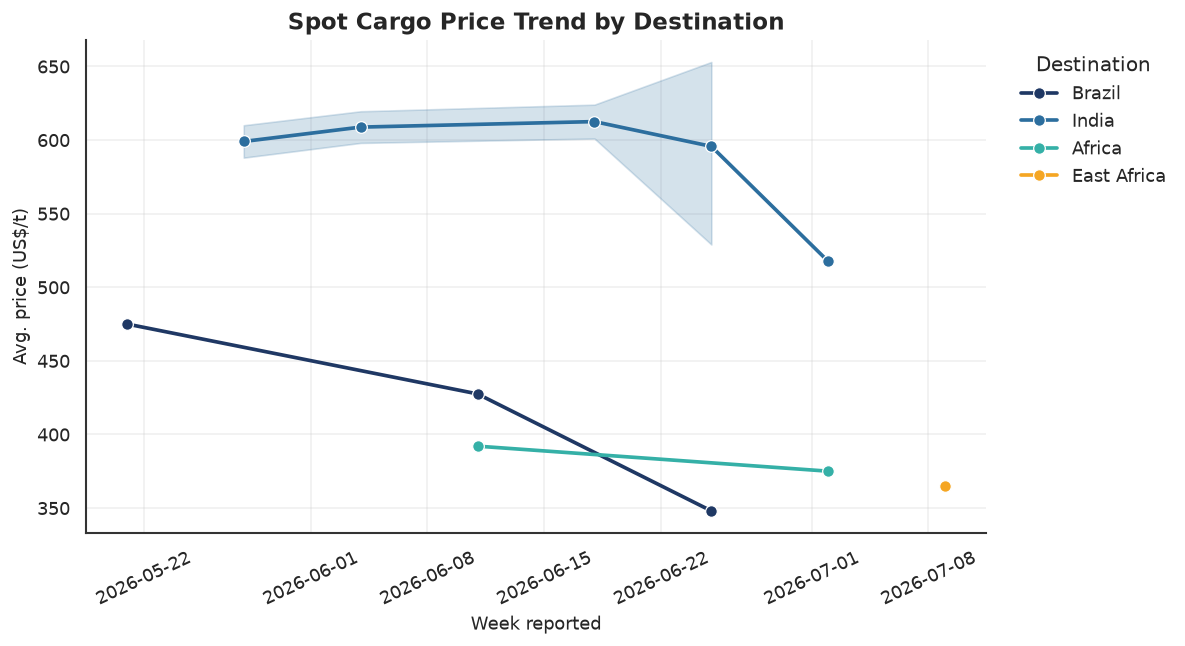

Avg price by destination (US$/t):
 destination
India          594.0
Brazil         417.0
Africa         384.0
East Africa    365.0
Name: avg_price_usd_t, dtype: float64


In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(data=spot, x="week_reported", y="avg_price_usd_t", hue="destination",
             marker="o", markersize=7, linewidth=2.2, ax=ax)
ax.set_title("Spot Cargo Price Trend by Destination")
ax.set_xlabel("Week reported")
ax.set_ylabel("Avg. price (US$/t)")
ax.legend(title="Destination", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("chart_01_price_trend_by_destination.png", bbox_inches="tight")
plt.show()

price_by_dest = spot.groupby("destination")["avg_price_usd_t"].mean().sort_values(ascending=False)
print("Avg price by destination (US$/t):\n", price_by_dest.round(0))

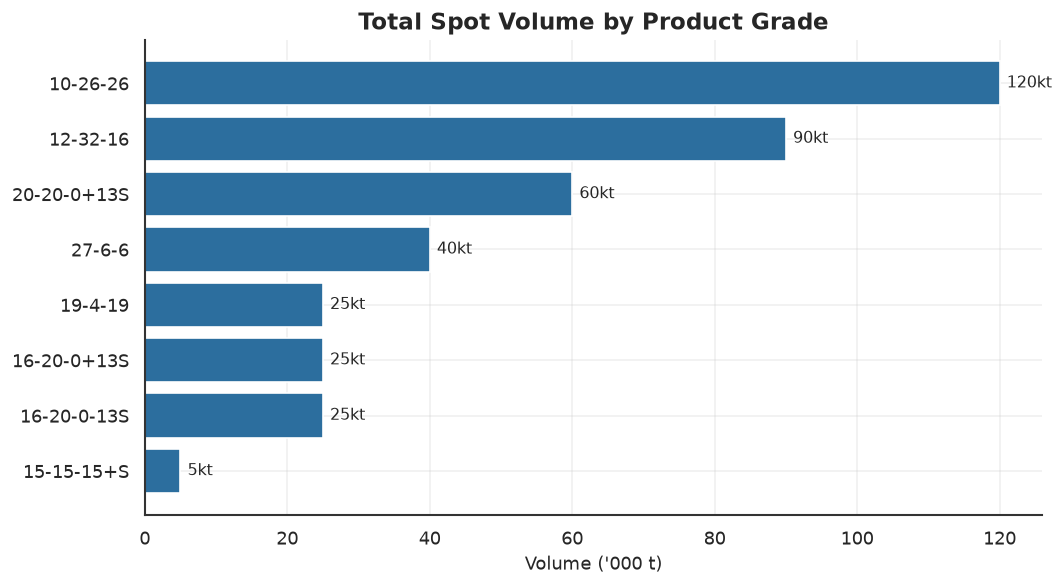

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
vol_by_product = spot.groupby("product")["volume_kt"].sum().sort_values(ascending=False)
bars = ax.barh(vol_by_product.index, vol_by_product.values, color=PALETTE[1])
ax.invert_yaxis()
ax.set_title("Total Spot Volume by Product Grade")
ax.set_xlabel("Volume ('000 t)")
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.0f}kt", va="center", fontsize=9.5)
plt.tight_layout()
plt.savefig("chart_02_volume_by_product.png", bbox_inches="tight")
plt.show()

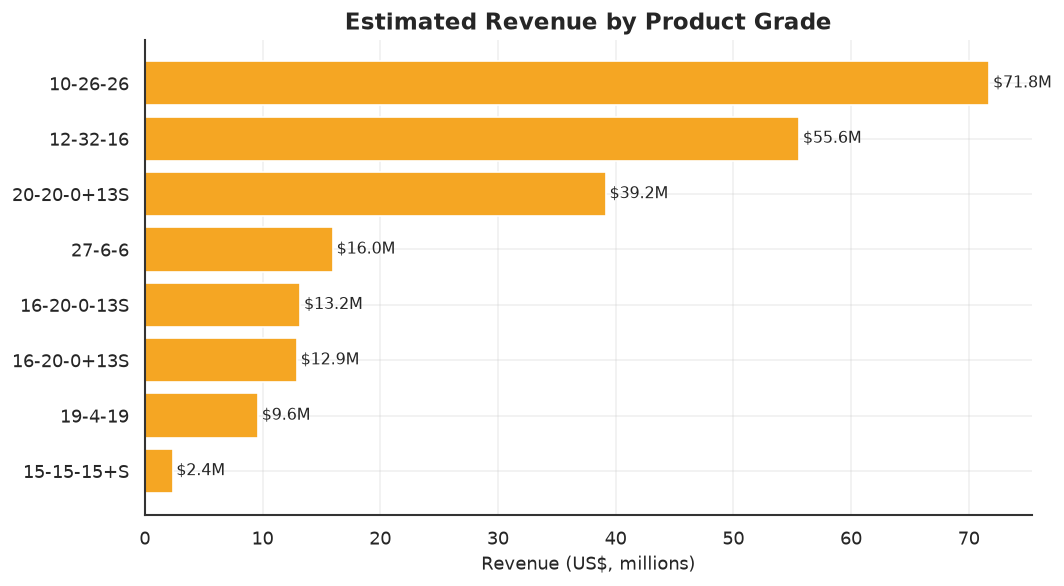

In [19]:
rev_by_product = spot.groupby("product")["revenue_usd"].sum().sort_values(ascending=False) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rev_by_product.index, rev_by_product.values, color=PALETTE[3])
ax.invert_yaxis()
ax.set_title("Estimated Revenue by Product Grade")
ax.set_xlabel("Revenue (US$, millions)")
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"${bar.get_width():.1f}M", va="center", fontsize=9.5)
plt.tight_layout()
plt.savefig("chart_03_revenue_by_product.png", bbox_inches="tight")
plt.show()

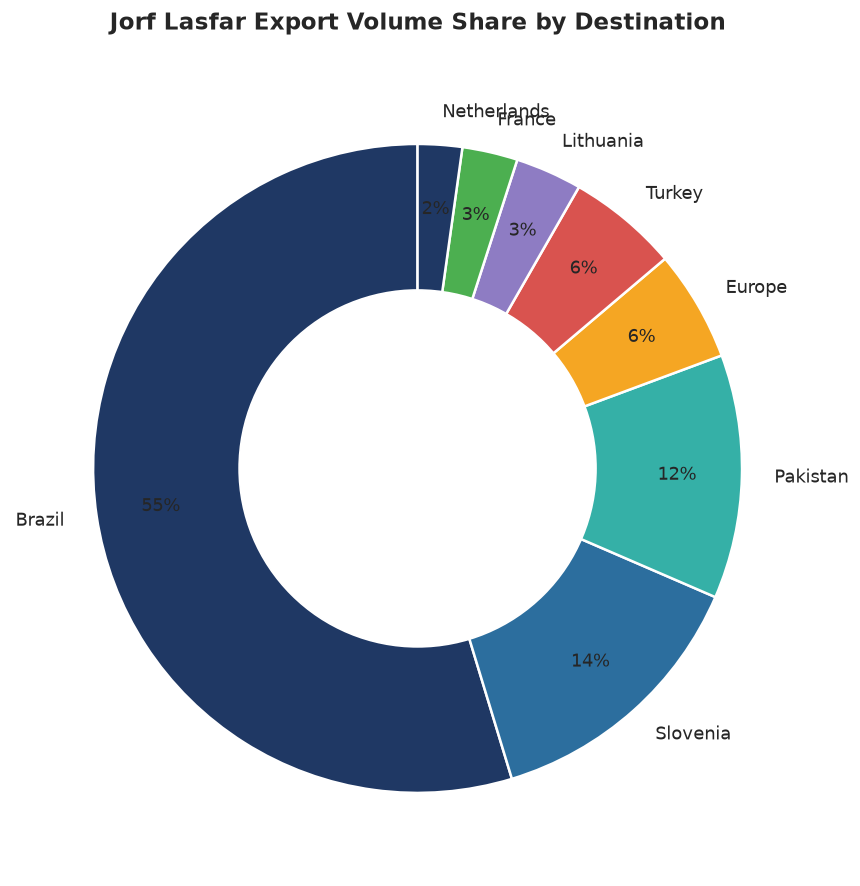

Concentration risk check: Brazil takes 55% of tracked export tonnage.


In [20]:
dest_vol = jorf.groupby("destination")["volume_t"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 7.5))
wedges, texts, autotexts = ax.pie(
    dest_vol.values, labels=dest_vol.index, autopct="%1.0f%%",
    colors=PALETTE, startangle=90, pctdistance=0.8,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
centre_circle = plt.Circle((0, 0), 0.55, fc="white")
ax.add_artist(centre_circle)
ax.set_title("Jorf Lasfar Export Volume Share by Destination", pad=20)
plt.tight_layout()
plt.savefig("chart_04_export_destination_share.png", bbox_inches="tight")
plt.show()

top_dest = dest_vol.index[0]
top_share = dest_vol.iloc[0] / dest_vol.sum()
print(f"Concentration risk check: {top_dest} takes {top_share:.0%} of tracked export tonnage.")

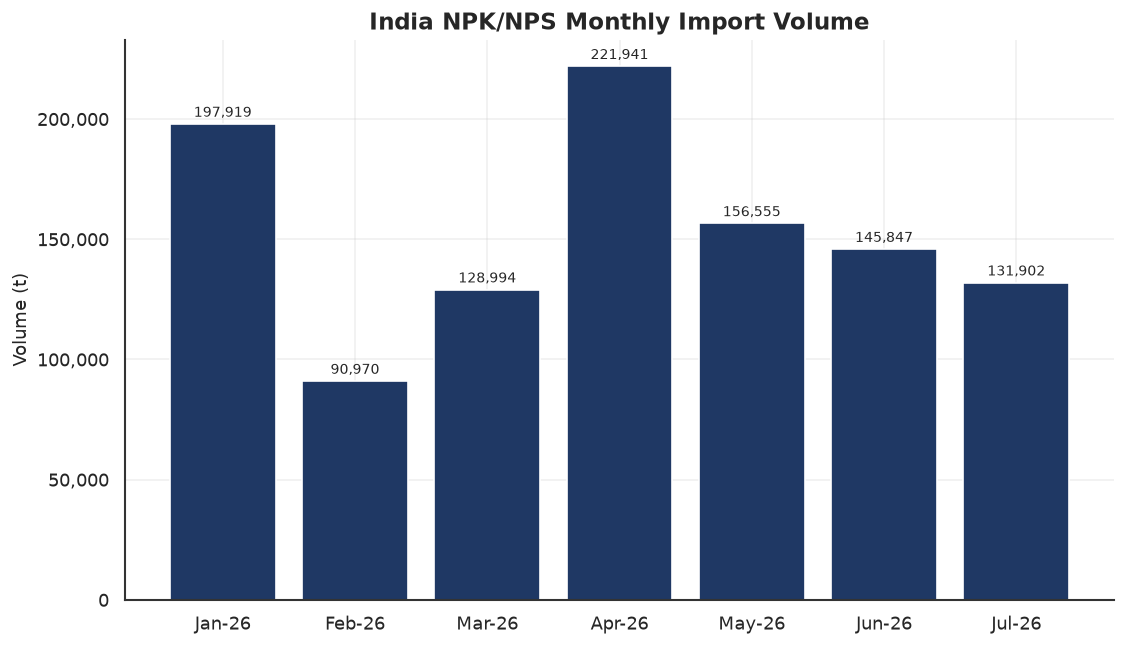

Peak month: Apr-26 (221,941 t)
Lowest month: Feb-26 (90,970 t)


In [21]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.bar(monthly["month"], monthly["reported_total_t"], color=PALETTE[0])
ax.set_title("India NPK/NPS Monthly Import Volume")
ax.set_ylabel("Volume (t)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f"{bar.get_height():,.0f}", ha="center", fontsize=8.5)
plt.tight_layout()
plt.savefig("chart_05_india_monthly_imports.png", bbox_inches="tight")
plt.show()

peak = monthly.loc[monthly["reported_total_t"].idxmax()]
low = monthly.loc[monthly["reported_total_t"].idxmin()]
print(f"Peak month: {peak['month']} ({peak['reported_total_t']:,.0f} t)")
print(f"Lowest month: {low['month']} ({low['reported_total_t']:,.0f} t)")

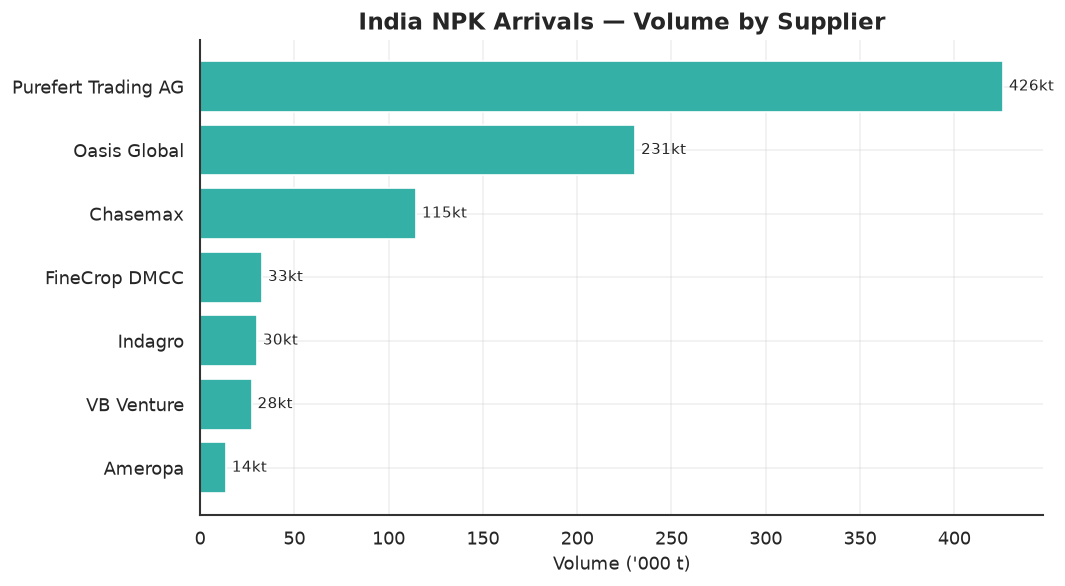

In [22]:
top_suppliers = arrivals.groupby("supplier")["volume_t"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_suppliers.index, top_suppliers.values / 1000, color=PALETTE[2])
ax.invert_yaxis()
ax.set_title("India NPK Arrivals — Volume by Supplier")
ax.set_xlabel("Volume ('000 t)")
for bar in bars:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.0f}kt", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("chart_06_top_suppliers_india.png", bbox_inches="tight")
plt.show()

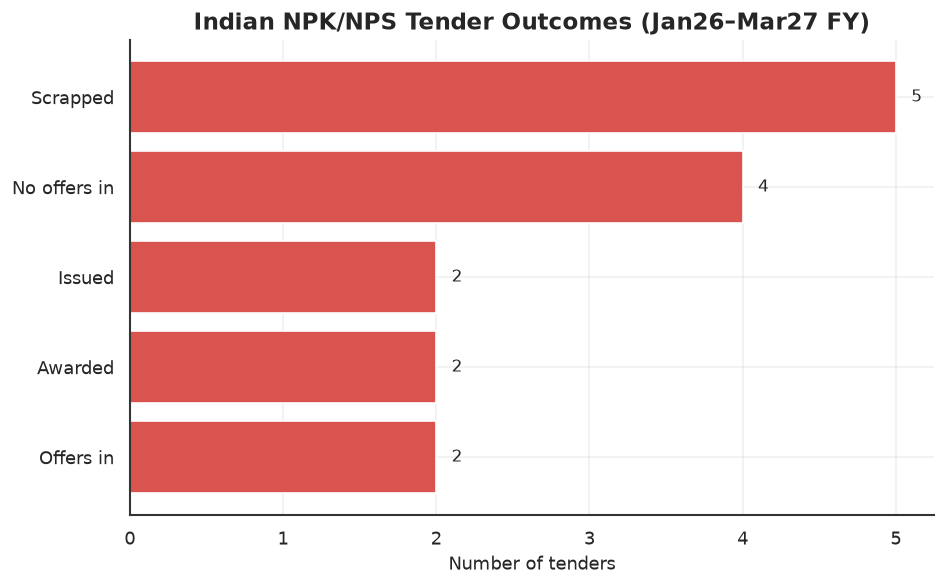

Scrapped: 33%  |  Awarded: 13%


In [24]:
status_counts = tenders["status"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(status_counts.index, status_counts.values, color=PALETTE[4])
ax.invert_yaxis()
ax.set_title("Indian NPK/NPS Tender Outcomes (Jan26–Mar27 FY)")
ax.set_xlabel("Number of tenders")
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{int(bar.get_width())}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("chart_07_tender_outcomes.png", bbox_inches="tight")
plt.show()

scrapped_pct = (tenders["status"] == "Scrapped").mean()
awarded_pct = (tenders["status"] == "Awarded").mean()
print(f"Scrapped: {scrapped_pct:.0%}  |  Awarded: {awarded_pct:.0%}")

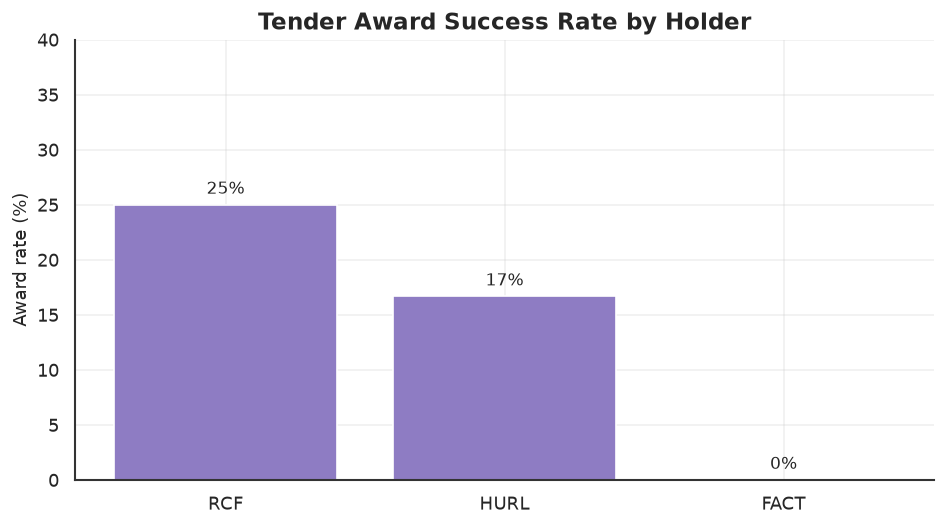

In [25]:
pivot = pd.crosstab(tenders["holder"], tenders["status"])
success_rate = (pivot.get("Awarded", 0) / pivot.sum(axis=1)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(success_rate.index, success_rate.values * 100, color=PALETTE[5])
ax.set_title("Tender Award Success Rate by Holder")
ax.set_ylabel("Award rate (%)")
ax.set_ylim(0, max(success_rate.values * 100, default=10) + 15)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.0f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("chart_08_tender_success_by_holder.png", bbox_inches="tight")
plt.show()

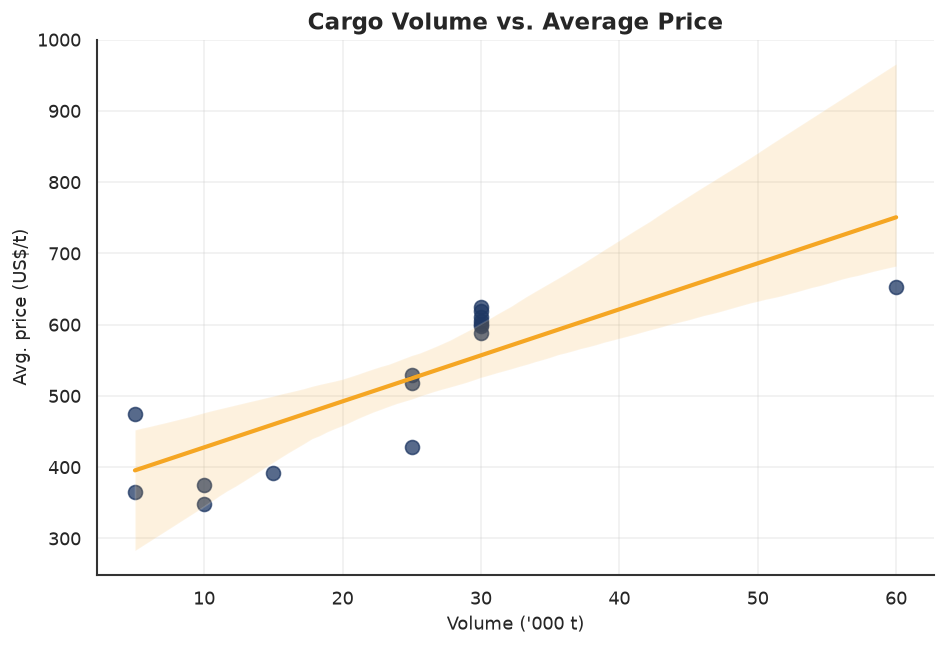

Correlation (volume vs price): 0.81


In [26]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=spot, x="volume_kt", y="avg_price_usd_t", ax=ax,
            scatter_kws={"s": 70, "alpha": 0.75, "color": PALETTE[0]},
            line_kws={"color": PALETTE[3], "linewidth": 2.5})
ax.set_title("Cargo Volume vs. Average Price")
ax.set_xlabel("Volume ('000 t)")
ax.set_ylabel("Avg. price (US$/t)")
plt.tight_layout()
plt.savefig("chart_09_volume_vs_price.png", bbox_inches="tight")
plt.show()

corr = np.corrcoef(spot["volume_kt"], spot["avg_price_usd_t"])[0, 1]
print(f"Correlation (volume vs price): {corr:.2f}")

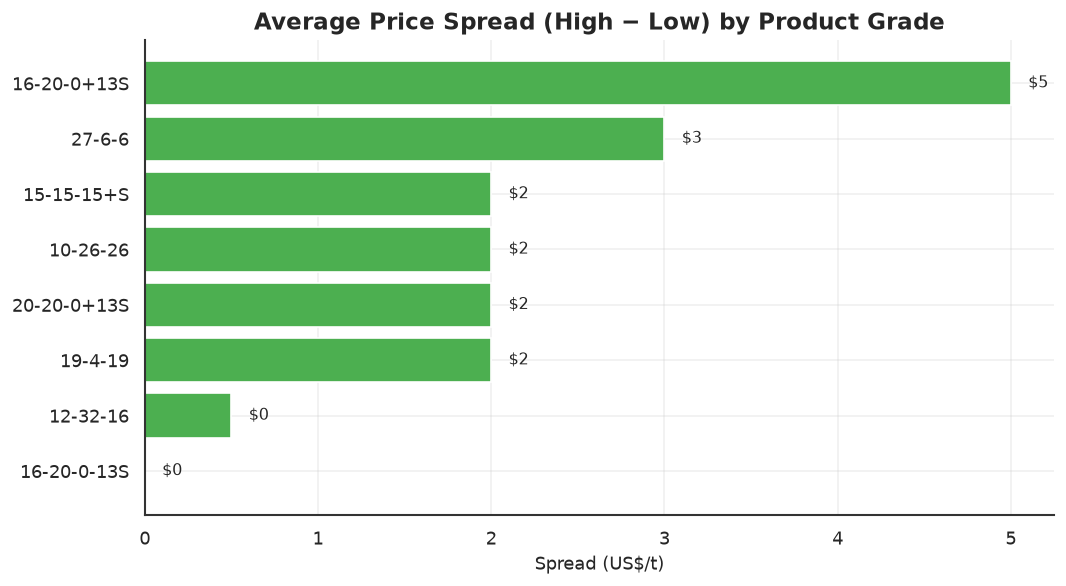

In [27]:
spot["spread_usd_t"] = spot["high_price_usd_t"] - spot["low_price_usd_t"]
spread_by_product = spot.groupby("product")["spread_usd_t"].mean().sort_values(ascending=False).dropna()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(spread_by_product.index, spread_by_product.values, color=PALETTE[6] if len(PALETTE) > 6 else PALETTE[1])
ax.invert_yaxis()
ax.set_title("Average Price Spread (High − Low) by Product Grade")
ax.set_xlabel("Spread (US$/t)")
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"${bar.get_width():.0f}", va="center", fontsize=9.5)
plt.tight_layout()
plt.savefig("chart_10_price_spread_by_product.png", bbox_inches="tight")
plt.show()

In [28]:
summary = f"""
EXECUTIVE SUMMARY — Fertilizer Trade & Tender Analysis
========================================================
1. Highest-paying spot market: {price_by_dest.index[0]} (${price_by_dest.iloc[0]:.0f}/t)
   Lowest-paying: {price_by_dest.index[-1]} (${price_by_dest.iloc[-1]:.0f}/t)

2. Highest-volume grade: {vol_by_product.index[0]} ({vol_by_product.iloc[0]:.0f}kt)
   Highest-revenue grade: {rev_by_product.index[0]} (${rev_by_product.iloc[0]:.1f}M)

3. Export concentration risk: {top_dest} takes {top_share:.0%} of Jorf Lasfar tonnage.

4. Import seasonality: peak month {peak['month']} ({peak['reported_total_t']:,.0f} t),
   lowest month {low['month']} ({low['reported_total_t']:,.0f} t).

5. Top supplier into India by volume: {top_suppliers.index[0]} ({top_suppliers.iloc[0]/1000:.0f}kt)

6. Tender health: {awarded_pct:.0%} awarded vs {scrapped_pct:.0%} scrapped —
   {'material' if scrapped_pct > 0.25 else 'limited'} price-negotiation friction.

7. Volume vs price correlation: {corr:.2f} — driven by which grades trade in
   large lots, not a general bulk discount effect.

8. Highest price-risk grade (widest spread): {spread_by_product.index[0]}
   (avg spread ${spread_by_product.iloc[0]:.0f}/t)
"""
print(summary)

with open("executive_summary.txt", "w") as f:
    f.write(summary)


EXECUTIVE SUMMARY — Fertilizer Trade & Tender Analysis
1. Highest-paying spot market: India ($594/t)
   Lowest-paying: East Africa ($365/t)

2. Highest-volume grade: 10-26-26 (120kt)
   Highest-revenue grade: 10-26-26 ($71.8M)

3. Export concentration risk: Brazil takes 55% of Jorf Lasfar tonnage.

4. Import seasonality: peak month Apr-26 (221,941 t),
   lowest month Feb-26 (90,970 t).

5. Top supplier into India by volume: Purefert Trading AG (426kt)

6. Tender health: 13% awarded vs 33% scrapped —
   material price-negotiation friction.

7. Volume vs price correlation: 0.81 — driven by which grades trade in
   large lots, not a general bulk discount effect.

8. Highest price-risk grade (widest spread): 16-20-0+13S
   (avg spread $5/t)

